# ASAP8 Detection of Change analysis

Minimal setup for cross-session Detection-of-Change analyses. This notebook deliberately stops before plotting or inferential analysis.

Canonical tables created here:
- `sessions`: one row per complete processed session
- `rois`: one row per session-specific ROI, including longitudinal identity and depth group
- `spikes`: canonical `template_v1` optical-spike table
- `events`: one row per expected image cycle, with independent change/omission marker times
- `trial_index`: lightweight map from single-trial H5 rows onto `events`

Mean-response, sequence-response, single-trial, and running loaders are imported for the analysis cells that follow.

In [17]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.voltage.dataset import (
    DEPTH_GROUP_ORDER,
    build_voltage_session_table,
    build_voltage_roi_table,
)
from vip_slap2_analysis.voltage.spikes import (
    DETECTOR_VERSION,
    build_spike_table,
)
from vip_slap2_analysis.behavior.change_detection import build_change_detection_events
from vip_slap2_analysis.voltage.responses import (
    build_single_trial_index,
    load_response_package,
    get_mean_response,
    get_sequence_response,
    load_single_trial_traces,
)
from vip_slap2_analysis.behavior.encoder import compute_encoder_velocity
from vip_slap2_analysis.utils.utils import save_figure
savepath = r'C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures'

assert DETECTOR_VERSION == "template_v1"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration

In [2]:
BASE_PATH = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics")

TARGET_MICE = [852835, 863774]
TARGET_SESSION_LABELS = None
TARGET_SESSION_IDS = None
PARADIGMS = ["change_detection_passive"]
EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]

TRACE_VARIANT = "dff_robust_f0_trial"
REGISTRATION_FILENAME = "roi_identity_registration.csv"
EXCLUDE_INVALID_ROIS = True
EXPECTED_F0_SMOOTH_SEC = 60.0

FORCE_SPIKE_RECOMPUTE = False
SPIKE_KWARGS = dict(
    height_sigma=3.0,
    template_sigma=3.5,
    prominence_sigma=0.5,
)

RUNNING_KWARGS = dict(
    wheel_radius_cm=4.69,
    encoder_units="ticks",
    ticks_per_revolution=8192,
    absolute_velocity=True,
)

## Session registry

Only sessions with the full-session trace, single-trial H5, mean NPZ, sequence NPZ, corrected Bonsai log, and imaging-epoch QC are admitted. Paths to the encoder are retained when available but are not required at this stage.

In [3]:
registry = VIPSessionRegistry.from_basepath(BASE_PATH)

sessions = build_voltage_session_table(
    registry,
    subject_ids=TARGET_MICE,
    paradigms=PARADIGMS,
    exclude_session_types=EXCLUDE_SESSION_TYPES,
    session_labels=TARGET_SESSION_LABELS,
    session_ids=TARGET_SESSION_IDS,
    trace_variant=TRACE_VARIANT,
    expected_f0_smooth_sec=EXPECTED_F0_SMOOTH_SEC,
)

display(sessions[[
    "subject_id", "session_id", "session_label", "session_order",
    "dmd1_depth_um", "dmd2_depth_um", "f0_smooth_sec",
    "trace_h5", "single_trial_h5", "encoder_pkl",
]])

C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\voltage\dataset.py:203: UserWarning: 852835_2026-07-24_12-13-41: F0 smoother is 10 s, expected 60 s
  warnings.warn(


,subject_id,session_id,session_label,session_order,dmd1_depth_um,dmd2_depth_um,f0_smooth_sec,trace_h5,single_trial_h5,encoder_pkl
0,852835,852835_2026-07-23_14-27-27,A0,0,40.0,170.0,60.0,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
1,852835,852835_2026-07-24_12-13-41,A1,1,40.0,170.0,10.0,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
2,852835,852835_2026-07-27_11-59-54,A2,2,40.0,170.0,60.0,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
3,852835,852835_2026-07-28_17-13-56,B0,3,40.0,170.0,60.0,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
4,852835,852835_2026-07-29_10-08-37,B1,4,40.0,170.0,60.0,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
5,852835,852835_2026-07-30_15-04-34,B2,5,40.0,170.0,60.0,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
6,852835,852835_2026-08-01_14-58-35,G1,6,40.0,170.0,60.0,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
7,863774,863774_2026-08-04_08-12-47,A0,0,190.0,120.0,60.0,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
8,863774,863774_2026-08-05_13-17-41,A1,1,190.0,120.0,60.0,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
9,863774,863774_2026-08-06_09-15-41,A2,2,190.0,120.0,60.0,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...


## ROI registry

The processed trace-H5 QC mask and manual registration QC are kept separately. `cell_id` uses the longitudinal `global_cell_id` when available and otherwise remains session-specific. Depth groups match the ephys notebook: `<100 µm`, `100–150 µm`, and `>150 µm`.

In [4]:
rois = build_voltage_roi_table(
    sessions,
    registration_filename=REGISTRATION_FILENAME,
    exclude_invalid_rois=EXCLUDE_INVALID_ROIS,
)

print(f"{rois['included'].sum()} / {len(rois)} ROI observations included")
display(rois)

99 / 105 ROI observations included


,subject_id,session_id,session_label,session_order,session_type,dmd,roi,depth_um,depth_group,trace_h5_valid_roi,source_roi_label,global_cell_id,registration_valid_roi,excluded,confidence,notes,valid_roi,manually_registered,cell_id,included
0,852835,852835_2026-07-23_14-27-27,A0,0,A0,1,0,40.0,<100 µm,True,DMD1_ROI0,852835_C003,True,False,high,NaN,True,True,852835_C003,True
1,852835,852835_2026-07-23_14-27-27,A0,0,A0,1,1,40.0,<100 µm,True,DMD1_ROI1,852835_C002,True,False,high,NaN,True,True,852835_C002,True
2,852835,852835_2026-07-23_14-27-27,A0,0,A0,1,2,40.0,<100 µm,True,DMD1_ROI2,852835_C001,True,False,high,NaN,True,True,852835_C001,True
3,852835,852835_2026-07-23_14-27-27,A0,0,A0,1,3,40.0,<100 µm,True,DMD1_ROI3,852835_C000,True,False,high,NaN,True,True,852835_C000,True
4,852835,852835_2026-07-23_14-27-27,A0,0,A0,2,0,170.0,>150 µm,True,DMD2_ROI0,852835_C006,True,False,high,NaN,True,True,852835_C006,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,863774,863774_2026-08-09_11-37-01,B2,5,B2,2,0,120.0,100–150 µm,True,DMD2_ROI0,863774_C003,True,False,high,NaN,True,True,863774_C003,True
101,863774,863774_2026-08-09_11-37-01,B2,5,B2,2,1,120.0,100–150 µm,False,DMD2_ROI1,863774_C002,False,False,high,NaN,False,True,863774_C002,False
102,863774,863774_2026-08-09_11-37-01,B2,5,B2,2,2,120.0,100–150 µm,True,DMD2_ROI2,863774_C001,True,False,high,NaN,True,True,863774_C001,True
103,863774,863774_2026-08-09_11-37-01,B2,5,B2,2,3,120.0,100–150 µm,True,DMD2_ROI3,863774_C004,True,False,high,NaN,True,True,863774_C004,True


## Spike extraction

Uses the same source-level `template_v1` detector as the ephys notebook. Each session is cached beside its processed voltage trace as `spikes_template_v1.parquet` (compressed CSV fallback if parquet support is unavailable), with metadata that invalidates the cache if the source H5, ROI selection, detector version, or detector parameters change.

In [5]:
spikes = build_spike_table(
    sessions,
    rois,
    force=FORCE_SPIKE_RECOMPUTE,
    detection_kwargs=SPIKE_KWARGS,
)

print(f"{len(spikes):,} spikes")
display(
    spikes.groupby(
        ["subject_id", "session_label", "dmd", "roi", "depth_group"],
        observed=True,
    ).size().rename("n_spikes").reset_index()
)

1,039,642 spikes


,subject_id,session_label,dmd,roi,depth_group,n_spikes
0,852835,A0,1,0,<100 µm,10097
1,852835,A0,1,1,<100 µm,7605
2,852835,A0,1,2,<100 µm,13160
3,852835,A0,1,3,<100 µm,8120
4,852835,A0,2,0,>150 µm,22474
...,...,...,...,...,...,...
94,863774,B2,1,3,>150 µm,13814
95,863774,B2,2,0,100–150 µm,13915
96,863774,B2,2,2,100–150 µm,5268
97,863774,B2,2,3,100–150 µm,8906


## Detection-of-Change event table

One row corresponds to one expected image cycle. `onset_sec` is the image-cycle timestamp used for image extraction. `change_onset_sec` and `omission_onset_sec` retain the special-event marker timestamps used for the longer change/omission extraction windows. This matters because a `ChangeFlash` marker can precede the changed-to image by one display frame.

The table also records expected versus actually presented sequence position, neighboring presented-image events, minute-scale time blocks, imaging epoch, and whether the complete image/change/omission extraction window was retained.

In [6]:
events = build_change_detection_events(sessions)

summary = (
    events.groupby(["subject_id", "session_label"])
    .agg(
        n_cycles=("event_id", "size"),
        n_changes=("is_change", "sum"),
        n_omissions=("is_omission", "sum"),
        retained_images=("retained_image_window", "sum"),
        retained_changes=("retained_change_window", "sum"),
        retained_omissions=("retained_omission_window", "sum"),
    )
    .reset_index()
)

display(summary)
display(events.head())

,subject_id,session_label,n_cycles,n_changes,n_omissions,retained_images,retained_changes,retained_omissions
0,852835,A0,2369,284,19,2363,284,19
1,852835,A1,2365,286,17,2363,286,17
2,852835,A2,2366,282,29,2317,277,29
3,852835,B0,2367,281,30,2364,281,30
4,852835,B1,2365,290,17,2362,290,17
5,852835,B2,2366,283,24,2323,279,23
6,852835,G1,1403,167,10,1271,156,10
7,863774,A0,2364,272,27,2362,272,27
8,863774,A1,2365,284,24,2264,272,23
9,863774,A2,2368,282,24,2332,277,23


,subject_id,session_id,session_label,session_order,event_id,event_uid,source_row,onset_sec,image_name,image_label,...,previous_presented_event_id,next_presented_event_id,previous_presented_image,next_presented_image,session_time_min,time_block,imaging_epoch,retained_image_window,retained_change_window,retained_omission_window
0,852835,852835_2026-07-23_14-27-27,A0,0,0,852835_2026-07-23_14-27-27:0,1,0.166217,stimuli\images_A\imk01057.tiff,imk01057,...,NaN,1.0,NaN,stimuli\images_A\imk01057.tiff,0.0,0,1.0,False,False,False
1,852835,852835_2026-07-23_14-27-27,A0,0,1,852835_2026-07-23_14-27-27:1,3,0.166217,stimuli\images_A\imk01057.tiff,imk01057,...,0.0,2.0,stimuli\images_A\imk01057.tiff,stimuli\images_A\imk01057.tiff,0.0,0,1.0,False,False,False
2,852835,852835_2026-07-23_14-27-27,A0,0,2,852835_2026-07-23_14-27-27:2,5,0.166217,stimuli\images_A\imk01057.tiff,imk01057,...,1.0,3.0,stimuli\images_A\imk01057.tiff,stimuli\images_A\imk01057.tiff,0.0,0,1.0,False,False,False
3,852835,852835_2026-07-23_14-27-27,A0,0,3,852835_2026-07-23_14-27-27:3,7,0.166217,stimuli\images_A\imk01057.tiff,imk01057,...,2.0,4.0,stimuli\images_A\imk01057.tiff,stimuli\images_A\imk01057.tiff,0.0,0,1.0,False,False,False
4,852835,852835_2026-07-23_14-27-27,A0,0,4,852835_2026-07-23_14-27-27:4,9,0.166217,stimuli\images_A\imk01057.tiff,imk01057,...,3.0,5.0,stimuli\images_A\imk01057.tiff,stimuli\images_A\imk01057.tiff,0.0,0,1.0,False,False,False


## Single-trial index

This reads only H5 metadata/onset vectors, not the trial traces themselves. Every stored image/change/omission trial is mapped one-to-one onto the canonical event table. A mismatch raises immediately rather than being repaired downstream with repeated nearest-onset joins.

In [7]:
trial_index = build_single_trial_index(sessions, events)

print(f"{len(trial_index):,} indexed single-trial response rows")
display(
    trial_index.groupby(
        ["subject_id", "session_label", "dmd", "event_type"]
    ).size().rename("n_trials").reset_index()
)
display(trial_index.head())

65,822 indexed single-trial response rows


,subject_id,session_label,dmd,event_type,n_trials
0,852835,A0,1,change,284
1,852835,A0,1,image,2363
2,852835,A0,1,omission,19
3,852835,A0,2,change,284
4,852835,A0,2,image,2363
...,...,...,...,...,...
73,863774,B2,1,image,2306
74,863774,B2,1,omission,17
75,863774,B2,2,change,277
76,863774,B2,2,image,2306


,session_id,dmd,event_type,image_name,trial_index,onset_sec,dataset_path,event_id,match_error_sec,matched,subject_id,session_label,session_order,event_uid
0,852835_2026-07-23_14-27-27,1,change,,0,12.344309,/DMD1/change/traces,21,0.0,True,852835,A0,0,852835_2026-07-23_14-27-27:21
1,852835_2026-07-23_14-27-27,1,change,,1,17.677052,/DMD1/change/traces,28,0.0,True,852835,A0,0,852835_2026-07-23_14-27-27:28
2,852835_2026-07-23_14-27-27,1,change,,2,26.777112,/DMD1/change/traces,40,0.0,True,852835,A0,0,852835_2026-07-23_14-27-27:40
3,852835_2026-07-23_14-27-27,1,change,,3,37.477022,/DMD1/change/traces,54,0.0,True,852835,A0,0,852835_2026-07-23_14-27-27:54
4,852835_2026-07-23_14-27-27,1,change,,4,42.810580,/DMD1/change/traces,61,0.0,True,852835,A0,0,852835_2026-07-23_14-27-27:61


## Ready for response analyses

The base is intentionally complete at this point. Later cells can load only what they need:

```python
session = sessions.iloc[0]
mean_pkg = load_response_package(session.mean_npz)
sequence_pkg = load_response_package(session.sequence_npz)

# Mean response for one source ROI/image
# t, y = get_mean_response(mean_pkg, dmd=1, source_roi=0,
#                          event_type="image", image_name=image_name)

# Sequence-position responses for one source ROI/image
# sequence = get_sequence_response(sequence_pkg, dmd=1, source_roi=0,
#                                  image_name=image_name, phase="repeated")

# Selected single trials only
# single = load_single_trial_traces(session.single_trial_h5, dmd=1,
#                                   event_type="omission", source_rois=[0])

# HARP-aligned running
# running = compute_encoder_velocity(session.encoder_pkl, **RUNNING_KWARGS)
```

The next analysis section should begin with image-entrained response motifs, using mean dF/F as the primary response-shape representation and the spike table as a complementary fast-output readout.

## Image-response peak latency across sessions

For each **ROI × image identity × session**, this section finds the latency of the largest positive mean dF/F response after image onset. The mean response is baseline-subtracted and lightly smoothed before peak detection so that the estimate is not dominated by a single high-frequency sample. Peak finding is restricted to a configurable post-onset window.

For the longitudinal figure, image-specific peak latencies are collapsed to the **median across image identities for each neuron/session**. Only manually registered neurons observed in at least two of the selected sessions are connected across days. This avoids treating the eight image identities from one neuron as independent observations.

The default depth colors match the lab-meeting convention:
- superficial, <100 µm: `#EBA287`
- middle, 100–150 µm: `#d1e2b0`
- deep, >150 µm: `#7bbcd5`

**Interpretation caveat:** a shift in the peak of the trial-averaged response is descriptive evidence for a timing change, but this plot alone does not prove that the shift exceeds trial-to-trial or event-alignment jitter. A stronger follow-up is to bootstrap single trials within each neuron × image × session and compare the observed longitudinal shift with the resulting within-session peak-latency uncertainty.


In [8]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import ndimage

# Sessions shown in the slide. Missing labels are ignored automatically.
PEAK_SESSION_LABELS = ["A0", "A1", "A2", "B0", "B1", "B2"]

# Peak-latency definition.
PEAK_WINDOW_S = (-0.40, 0.45)
BASELINE_WINDOW_S = (-0.20, 0.0)
PEAK_SMOOTH_MS = 10.0

# Set to a positive value if you later want to exclude extremely weak cell × image responses.
MIN_PEAK_DFF = None

# Depth histogram can represent all included ROI observations or collapse repeated
# manually registered observations to one row per cell.
DEPTH_HIST_UNIT = "roi_observations"  # {"roi_observations", "unique_cells"}

# Lab-meeting depth palette. DEPTH_GROUP_ORDER is supplied by the analysis package.
_depth_palette = ["#EBA287", "#d1e2b0", "#7bbcd5"]
DEPTH_COLOR = {
    str(group): color
    for group, color in zip(list(DEPTH_GROUP_ORDER), _depth_palette)
}

if len(DEPTH_COLOR) != 3:
    raise ValueError(
        f"Expected three depth groups, got {list(DEPTH_GROUP_ORDER)}. "
        "Update DEPTH_COLOR explicitly if the registry convention changed."
    )

def depth_group_from_um(depth_um):
    depth_um = float(depth_um)
    if depth_um < 100:
        return str(DEPTH_GROUP_ORDER[0])
    if depth_um <= 150:
        return str(DEPTH_GROUP_ORDER[1])
    return str(DEPTH_GROUP_ORDER[2])

def smooth_finite(y, sigma_samples):
    # Gaussian smooth after linearly filling isolated NaNs.
    y = np.asarray(y, dtype=float).reshape(-1)
    good = np.isfinite(y)
    if good.sum() < 3:
        return np.full_like(y, np.nan)
    x = np.arange(y.size)
    filled = np.interp(x, x[good], y[good])
    if sigma_samples <= 0:
        return filled
    return ndimage.gaussian_filter1d(filled, sigma=sigma_samples, mode="nearest")

print("Depth groups:", DEPTH_COLOR)


Depth groups: {'<100 µm': '#EBA287', '100–150 µm': '#d1e2b0', '>150 µm': '#7bbcd5'}


In [9]:
# Extract one peak latency for every included ROI × image identity × selected session.

selected_sessions = sessions[
    sessions["session_label"].astype(str).isin(PEAK_SESSION_LABELS)
].copy()

if selected_sessions.empty:
    raise ValueError(
        f"None of {PEAK_SESSION_LABELS} are present in sessions['session_label']."
    )

available_labels = (
    selected_sessions.sort_values("session_order")["session_label"]
    .astype(str).drop_duplicates().tolist()
)
print("Peak-latency sessions:", available_labels)

mean_packages = {}
peak_rows = []

for session in selected_sessions.itertuples(index=False):
    session_id = str(session.session_id)
    mean_pkg = load_response_package(session.mean_npz)
    mean_packages[session_id] = mean_pkg

    session_rois = rois[
        (rois["session_id"].astype(str) == session_id)
        & rois["included"].astype(bool)
    ].copy()

    for roi_row in session_rois.itertuples(index=False):
        dmd = int(roi_row.dmd)
        source_roi = int(roi_row.roi)
        dmd_key = f"DMD{dmd}"

        if dmd_key not in mean_pkg:
            continue

        image_identity = mean_pkg[dmd_key].get("image_identity", {})
        for image_name in image_identity:
            try:
                t, y = get_mean_response(
                    mean_pkg,
                    dmd=dmd,
                    source_roi=source_roi,
                    event_type="image",
                    image_name=image_name,
                )
            except (KeyError, IndexError, ValueError):
                continue

            t = np.asarray(t, dtype=float).reshape(-1)
            y = np.asarray(y, dtype=float).squeeze()
            if y.ndim != 1 or y.size != t.size or y.size < 3:
                continue

            baseline = (t >= BASELINE_WINDOW_S[0]) & (t < BASELINE_WINDOW_S[1])
            if baseline.any():
                y = y - np.nanmean(y[baseline])

            dt = np.nanmedian(np.diff(t))
            if not np.isfinite(dt) or dt <= 0:
                continue

            sigma_samples = (PEAK_SMOOTH_MS / 1000.0) / dt
            y_smooth = smooth_finite(y, sigma_samples)

            search = (
                (t >= PEAK_WINDOW_S[0])
                & (t <= PEAK_WINDOW_S[1])
                & np.isfinite(y_smooth)
            )
            if not search.any():
                continue

            search_idx = np.flatnonzero(search)
            peak_idx = search_idx[np.nanargmax(y_smooth[search])]
            peak_dff = float(y_smooth[peak_idx])

            if MIN_PEAK_DFF is not None and peak_dff < float(MIN_PEAK_DFF):
                continue

            peak_rows.append({
                "subject_id": str(roi_row.subject_id),
                "session_id": session_id,
                "session_label": str(roi_row.session_label),
                "session_order": int(roi_row.session_order),
                "dmd": dmd,
                "roi": source_roi,
                "cell_id": str(roi_row.cell_id),
                "global_cell_id": str(getattr(roi_row, "global_cell_id", "")),
                "manually_registered": bool(getattr(roi_row, "manually_registered", False)),
                "depth_um": float(roi_row.depth_um),
                "depth_group": str(roi_row.depth_group),
                "image_name": str(image_name),
                "peak_latency_s": float(t[peak_idx]),
                "peak_dff": peak_dff,
            })

image_peak_latency = pd.DataFrame(peak_rows)

if image_peak_latency.empty:
    raise RuntimeError("No image-response peak latencies could be extracted.")

# Do not require identical image identities across image sets.
# Peak latency will subsequently be collapsed across the images present
# within each neuron × session.

print(
    image_peak_latency
    .groupby(["subject_id", "session_label"], observed=True)["image_name"]
    .nunique()
    .rename("n_images")
)
display(image_peak_latency.head())
print(
    f"{len(image_peak_latency):,} ROI × image × session peak estimates · "
    f"{image_peak_latency['cell_id'].nunique():,} cell IDs"
)


Peak-latency sessions: ['A0', 'A1', 'A2', 'B0', 'B1', 'B2']
subject_id  session_label
852835      A0               8
            A1               8
            A2               8
            B0               8
            B1               8
            B2               8
863774      A0               8
            A1               8
            A2               8
            B0               8
            B1               8
            B2               8
Name: n_images, dtype: int64


,subject_id,session_id,session_label,session_order,dmd,roi,cell_id,global_cell_id,manually_registered,depth_um,depth_group,image_name,peak_latency_s,peak_dff
0,852835,852835_2026-07-23_14-27-27,A0,0,1,0,852835_C003,852835_C003,True,40.0,<100 µm,stimuli\images_A\imk00459.tiff,0.326419,0.028058
1,852835,852835_2026-07-23_14-27-27,A0,0,1,0,852835_C003,852835_C003,True,40.0,<100 µm,stimuli\images_A\imk00895.tiff,0.104180,0.025238
2,852835,852835_2026-07-23_14-27-27,A0,0,1,0,852835_C003,852835_C003,True,40.0,<100 µm,stimuli\images_A\imk00942.tiff,0.248846,0.024273
3,852835,852835_2026-07-23_14-27-27,A0,0,1,0,852835_C003,852835_C003,True,40.0,<100 µm,stimuli\images_A\imk01057.tiff,-0.179258,0.023317
4,852835,852835_2026-07-23_14-27-27,A0,0,1,0,852835_C003,852835_C003,True,40.0,<100 µm,stimuli\images_A\imk01097.tiff,0.312664,0.028203


744 ROI × image × session peak estimates · 17 cell IDs


In [10]:
# Collapse the image-specific estimates to one value per neuron/session.
# The median is deliberately robust to one image having an unstable or atypical peak.

group_cols = [
    "subject_id", "session_id", "session_label", "session_order",
    "cell_id", "global_cell_id", "manually_registered",
]

cell_session_peak = (
    image_peak_latency
    .groupby(group_cols, observed=True, dropna=False)
    .agg(
        peak_latency_s=("peak_latency_s", "median"),
        peak_latency_q25_s=("peak_latency_s", lambda x: np.nanquantile(x, 0.25)),
        peak_latency_q75_s=("peak_latency_s", lambda x: np.nanquantile(x, 0.75)),
        median_peak_dff=("peak_dff", "median"),
        n_images=("image_name", "nunique"),
        depth_um=("depth_um", "median"),
    )
    .reset_index()
)
cell_session_peak["depth_group"] = cell_session_peak["depth_um"].map(depth_group_from_um)

# Conservative longitudinal subset: true manual identities only, observed in >=2 selected sessions.
tracked = cell_session_peak[cell_session_peak["manually_registered"]].copy()
tracked = tracked.groupby(
    ["subject_id", "global_cell_id"], group_keys=False, observed=True
).filter(lambda x: x["session_id"].nunique() >= 2)

if tracked.empty:
    print(
        "No manually registered neurons were observed in >=2 selected sessions. "
        "The extraction table is still available, but the paired longitudinal plot will be empty."
    )
else:
    # Give each longitudinal neuron one stable depth assignment using median depth across sessions.
    cell_depth = (
        tracked.groupby(["subject_id", "global_cell_id"], observed=True)["depth_um"]
        .median().rename("cell_depth_um").reset_index()
    )
    cell_depth["cell_depth_group"] = cell_depth["cell_depth_um"].map(depth_group_from_um)
    tracked = tracked.merge(
        cell_depth,
        on=["subject_id", "global_cell_id"],
        how="left",
        validate="many_to_one",
    )

display(cell_session_peak.head())
print(
    f"{len(tracked):,} registered cell-session observations from "
    f"{tracked[['subject_id','global_cell_id']].drop_duplicates().shape[0]:,} tracked neurons"
)


,subject_id,session_id,session_label,session_order,cell_id,global_cell_id,manually_registered,peak_latency_s,peak_latency_q25_s,peak_latency_q75_s,median_peak_dff,n_images,depth_um,depth_group
0,852835,852835_2026-07-23_14-27-27,A0,0,852835_C000,852835_C000,True,0.203696,0.135691,0.270368,0.026040,8,40.0,<100 µm
1,852835,852835_2026-07-23_14-27-27,A0,0,852835_C001,852835_C001,True,-0.208032,-0.250000,-0.182626,0.051337,8,40.0,<100 µm
2,852835,852835_2026-07-23_14-27-27,A0,0,852835_C002,852835_C002,True,0.304429,0.291305,0.312968,0.071113,8,40.0,<100 µm
3,852835,852835_2026-07-23_14-27-27,A0,0,852835_C003,852835_C003,True,0.259279,0.036081,0.290346,0.024756,8,40.0,<100 µm
4,852835,852835_2026-07-23_14-27-27,A0,0,852835_C004,852835_C004,True,-0.237180,-0.250000,-0.220992,0.085377,8,170.0,>150 µm


93 registered cell-session observations from 17 tracked neurons


In [11]:
depth_session_summary = (
    cell_session_peak
    .groupby(["depth_group", "session_label", "session_order"], observed=True, dropna=False)
    .agg(
        median_peak_latency_s=("peak_latency_s", "median"),
        q25_peak_latency_s=("peak_latency_s", lambda x: np.nanquantile(x, 0.25)),
        q75_peak_latency_s=("peak_latency_s", lambda x: np.nanquantile(x, 0.75)),
        n_cells=("cell_id", "nunique"),
    )
    .reset_index()
)

In [12]:
# Descriptive paired-shift summaries.
# Many neurons are nested within only a small number of mice, so these are intentionally
# descriptive rather than cell-level inferential p-values.

shift_rows = []

if len(tracked):
    first_label = available_labels[0]
    for later_label in available_labels[1:]:
        wide = tracked.pivot_table(
            index=["subject_id", "global_cell_id", "cell_depth_group"],
            columns="session_label",
            values="peak_latency_s",
            aggfunc="median",
        )
        if first_label not in wide.columns or later_label not in wide.columns:
            continue

        paired = wide[[first_label, later_label]].dropna().copy()
        if paired.empty:
            continue

        paired["delta_ms"] = (
            paired[later_label] - paired[first_label]
        ) * 1000.0

        for depth_group, sub in paired.groupby(level="cell_depth_group", observed=True):
            values = sub["delta_ms"].to_numpy(dtype=float)
            shift_rows.append({
                "comparison": f"{later_label} − {first_label}",
                "depth_group": str(depth_group),
                "n_cells": len(values),
                "median_delta_ms": float(np.nanmedian(values)),
                "fraction_later": float(np.mean(values > 0)),
            })

        values = paired["delta_ms"].to_numpy(dtype=float)
        shift_rows.append({
            "comparison": f"{later_label} − {first_label}",
            "depth_group": "all",
            "n_cells": len(values),
            "median_delta_ms": float(np.nanmedian(values)),
            "fraction_later": float(np.mean(values > 0)),
        })

        # Mouse-level summaries show whether one animal drives the effect.
        per_mouse = (
            paired.reset_index()
            .groupby("subject_id", observed=True)["delta_ms"]
            .median()
            .rename("mouse_median_delta_ms")
            .reset_index()
        )
        print(f"\n{later_label} − {first_label}, mouse-level median shifts (ms):")
        display(per_mouse)

shift_summary = pd.DataFrame(shift_rows)
if len(shift_summary):
    display(shift_summary)



A1 − A0, mouse-level median shifts (ms):


,subject_id,mouse_median_delta_ms
0,852835,-279.460378
1,863774,298.456011



A2 − A0, mouse-level median shifts (ms):


,subject_id,mouse_median_delta_ms
0,852835,-344.962560
1,863774,348.845903



B0 − A0, mouse-level median shifts (ms):


...


B1 − A0, mouse-level median shifts (ms):


,subject_id,mouse_median_delta_ms
0,852835,-38.271989
1,863774,347.231742



B2 − A0, mouse-level median shifts (ms):


,subject_id,mouse_median_delta_ms
0,852835,-181.019957
1,863774,546.943215


,comparison,depth_group,n_cells,median_delta_ms,fraction_later
0,A1 − A0,100–150 µm,3,234.029937,0.666667
1,A1 − A0,<100 µm,4,-322.481275,0.250000
2,A1 − A0,>150 µm,7,298.456011,0.714286
3,A1 − A0,all,14,228.953518,0.571429
4,A2 − A0,100–150 µm,3,174.750463,0.666667
5,A2 − A0,<100 µm,4,-354.273227,0.250000
6,A2 − A0,>150 µm,7,348.845903,0.714286
7,A2 − A0,all,14,203.618210,0.571429
8,B0 − A0,100–150 µm,3,309.029934,0.666667
9,B0 − A0,<100 µm,4,18.247036,0.500000


### Slide-ready figure

The large panel shows each registered neuron's median image-response peak latency across A0/A1/A2. Thin lines are individual neurons; thick lines are depth-group medians. The narrow panel shows the dataset's cortical-depth sampling with the three depth bands shaded using the same palette.

If the between-session displacement is real, the cleanest visual signature is a systematic upward movement of individual trajectories, not merely a change in the pooled distribution.


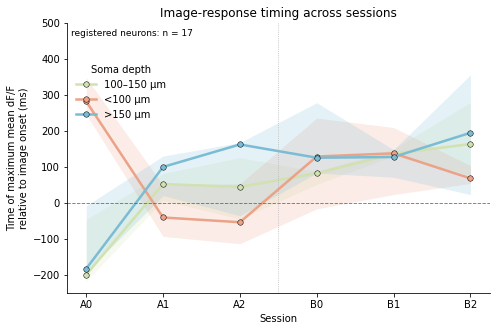

,subject_id,global_cell_id,image_name,depth_um,peak_latency_s,peak_dff
48,852835,852835_C004,stimuli\images_A\imk00459.tiff,170.0,-0.186556,0.153384
49,852835,852835_C004,stimuli\images_A\imk00895.tiff,170.0,-0.250000,0.139511
50,852835,852835_C004,stimuli\images_A\imk00942.tiff,170.0,-0.241017,0.162724
51,852835,852835_C004,stimuli\images_A\imk01057.tiff,170.0,-0.232034,0.126814
52,852835,852835_C004,stimuli\images_A\imk01097.tiff,170.0,-0.233344,0.144635
53,852835,852835_C004,stimuli\images_A\imk01220.tiff,170.0,-0.250000,0.124411
54,852835,852835_C004,stimuli\images_A\imk01378.tiff,170.0,-0.187867,0.113258
55,852835,852835_C004,stimuli\images_A\imk01643.tiff,170.0,-0.250000,0.090392
40,852835,852835_C005,stimuli\images_A\imk00459.tiff,170.0,0.145165,0.074005
41,852835,852835_C005,stimuli\images_A\imk00895.tiff,170.0,0.178104,0.071014


In [46]:
# %% Un-baselined image-response peak timing

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import ndimage

PEAK_SESSION_LABELS = ["A0","A1","A2","B0","B1","B2"]
PEAK_WINDOW_S = (-0.25,0.5)
PEAK_SMOOTH_MS = 10.0

def depth_group_from_um(d):
    return str(DEPTH_GROUP_ORDER[0] if d < 100 else DEPTH_GROUP_ORDER[1] if d <= 150 else DEPTH_GROUP_ORDER[2])

def smooth_finite(y,sigma):
    y = np.asarray(y,float).reshape(-1); good = np.isfinite(y)
    if good.sum() < 3: return np.full_like(y,np.nan)
    y = np.interp(np.arange(y.size),np.flatnonzero(good),y[good])
    return ndimage.gaussian_filter1d(y,sigma,mode="nearest")

selected_sessions = sessions[sessions["session_label"].astype(str).isin(PEAK_SESSION_LABELS)].copy()
available_labels = [x for x in PEAK_SESSION_LABELS if x in set(selected_sessions["session_label"].astype(str))]
peak_rows = []

for session in selected_sessions.itertuples(index=False):
    sid = str(session.session_id); pkg = load_response_package(session.mean_npz)
    sr = rois[(rois["session_id"].astype(str)==sid) & rois["included"].astype(bool)]
    for r in sr.itertuples(index=False):
        dmd,roi = int(r.dmd),int(r.roi); key = f"DMD{dmd}"
        if key not in pkg: continue
        for image in pkg[key].get("image_identity",{}):
            try: t,y = get_mean_response(pkg,dmd=dmd,source_roi=roi,event_type="image",image_name=image)
            except (KeyError,IndexError,ValueError): continue
            t = np.asarray(t,float).reshape(-1); y = np.asarray(y,float).squeeze()
            if y.ndim != 1 or len(y) != len(t) or len(y) < 3: continue
            dt = np.nanmedian(np.diff(t))
            if not np.isfinite(dt) or dt <= 0: continue

            # Smooth raw mean dF/F only; NO baseline subtraction.
            ys = smooth_finite(y,(PEAK_SMOOTH_MS/1000)/dt)
            search = (t >= PEAK_WINDOW_S[0]) & (t <= PEAK_WINDOW_S[1]) & np.isfinite(ys)
            if not search.any(): continue

            # Maximum positive ASAP8 response. t is already relative to image onset (t=0).
            idx = np.flatnonzero(search)
            p = idx[np.nanargmax(ys[search])]

            peak_rows.append(dict(
                subject_id=str(r.subject_id),session_id=sid,session_label=str(r.session_label),
                cell_id=str(r.cell_id),global_cell_id=str(getattr(r,"global_cell_id","")),
                manually_registered=bool(getattr(r,"manually_registered",False)),
                depth_um=float(r.depth_um),image_name=str(image),
                peak_latency_s=float(t[p]-0.0),peak_dff=float(ys[p])
            ))

image_peak_latency = pd.DataFrame(peak_rows)
if image_peak_latency.empty: raise RuntimeError("No image-response peaks extracted.")

# Median across image identities -> one peak time per neuron/session.
group_cols = ["subject_id","session_id","session_label","cell_id","global_cell_id","manually_registered"]
cell_session_peak = image_peak_latency.groupby(group_cols,observed=True,dropna=False).agg(
    peak_latency_s=("peak_latency_s","median"),
    peak_latency_q25_s=("peak_latency_s",lambda x: np.nanquantile(x,.25)),
    peak_latency_q75_s=("peak_latency_s",lambda x: np.nanquantile(x,.75)),
    n_images=("image_name","nunique"),
    depth_um=("depth_um","median")
).reset_index()
cell_session_peak["depth_group"] = cell_session_peak["depth_um"].map(depth_group_from_um)

# Same registered neurons observed longitudinally.
tracked = cell_session_peak[cell_session_peak["manually_registered"]].copy()
tracked = tracked.groupby(["subject_id","global_cell_id"],group_keys=False,observed=True).filter(
    lambda x: x["session_id"].nunique() >= 2
)

if len(tracked):
    cd = tracked.groupby(["subject_id","global_cell_id"],observed=True)["depth_um"].median().rename("cell_depth_um").reset_index()
    cd["cell_depth_group"] = cd["cell_depth_um"].map(depth_group_from_um)
    tracked = tracked.merge(cd,on=["subject_id","global_cell_id"],how="left",validate="many_to_one")

# Do NOT group by session_order: pool the same session label across mice.
depth_session_summary = tracked.groupby(["cell_depth_group","session_label"],observed=True).agg(
    median_peak_latency_s=("peak_latency_s","median"),
    q25_peak_latency_s=("peak_latency_s",lambda x: np.nanquantile(x,.25)),
    q75_peak_latency_s=("peak_latency_s",lambda x: np.nanquantile(x,.75)),
    n_cells=("global_cell_id","nunique")
).reset_index().rename(columns={"cell_depth_group":"depth_group"})

fig,ax = plt.subplots(figsize=(7,4.7))
xmap = {l:i for i,l in enumerate(available_labels)}
xs = np.arange(len(available_labels))

for group,sub in depth_session_summary.groupby("depth_group",observed=True):
    sub = sub.assign(x=sub["session_label"].astype(str).map(xmap)).dropna(subset=["x"]).sort_values("x")
    x = sub["x"].to_numpy(float)
    y = 1000*sub["median_peak_latency_s"].to_numpy(float)
    lo = 1000*sub["q25_peak_latency_s"].to_numpy(float)
    hi = 1000*sub["q75_peak_latency_s"].to_numpy(float)
    c = DEPTH_COLOR[str(group)]
    ax.fill_between(x,lo,hi,color=c,alpha=.20,lw=0)
    ax.plot(x,y,"-o",color=c,lw=2.5,ms=5.5,mfc=c,mec="black",mew=.5,label=str(group))

ax.axhline(0,color=".35",lw=.9,ls="--",alpha=.8)
if "A2" in xmap and "B0" in xmap:
    ax.axvline((xmap["A2"]+xmap["B0"])/2,color=".7",lw=.8,ls=":")
ax.set(
    xticks=xs,xticklabels=available_labels,xlabel="Session",
    ylabel="Time of maximum mean dF/F\nrelative to image onset (ms)",
    xlim=(-.25,len(available_labels)-.75),
    ylim=(1000*PEAK_WINDOW_S[0],1000*PEAK_WINDOW_S[1])
)
ax.spines[["top","right"]].set_visible(False)
ax.set_title("Image-response timing across sessions")

n = tracked[["subject_id","global_cell_id"]].drop_duplicates().shape[0]
ax.text(.01,.98,f"registered neurons: n = {n}",transform=ax.transAxes,ha="left",va="top",fontsize=9)
ax.legend(title="Soma depth",frameon=False,loc="upper left",bbox_to_anchor=(0,.88))
plt.tight_layout()
plt.show()

save_figure(fig,os.path.join(savepath,"latency_shift"),formats=[".pdf"],dpi=300)

# Useful spot-check: per-image peaks driving the deep A0 estimate.
display(
    image_peak_latency[
        (image_peak_latency["session_label"]=="A0") &
        (image_peak_latency["depth_um"]>150)
    ][["subject_id","global_cell_id","image_name","depth_um","peak_latency_s","peak_dff"]]
    .sort_values(["subject_id","global_cell_id","image_name"])
)

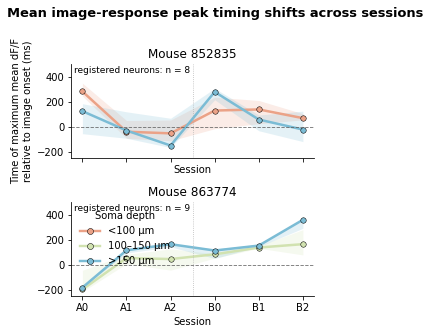

In [55]:
# %% Peak timing by mouse

mouse_session_summary = tracked.groupby(
    ["subject_id","cell_depth_group","session_label"], observed=True
).agg(
    median_peak_latency_s=("peak_latency_s","median"),
    q25_peak_latency_s=("peak_latency_s",lambda x: np.nanquantile(x,.25)),
    q75_peak_latency_s=("peak_latency_s",lambda x: np.nanquantile(x,.75)),
    n_cells=("global_cell_id","nunique")
).reset_index().rename(columns={"cell_depth_group":"depth_group"})

mice = sorted(tracked["subject_id"].astype(str).unique())
xmap = {l:i for i,l in enumerate(available_labels)}
xs = np.arange(len(available_labels))

fig,axs = plt.subplots(len(mice),1,figsize=(4.5,4.5),sharex=True,sharey=True)
axs = np.atleast_1d(axs)

for ax,mouse in zip(axs,mice):
    m = mouse_session_summary[mouse_session_summary["subject_id"].astype(str)==mouse]

    for group,sub in m.groupby("depth_group",observed=True):
        sub = sub.assign(x=sub["session_label"].astype(str).map(xmap)).dropna(subset=["x"]).sort_values("x")
        if sub.empty: continue
        x = sub["x"].to_numpy(float)
        y = 1000*sub["median_peak_latency_s"].to_numpy(float)
        lo = 1000*sub["q25_peak_latency_s"].to_numpy(float)
        hi = 1000*sub["q75_peak_latency_s"].to_numpy(float)
        c = DEPTH_COLOR[str(group)]
        ax.fill_between(x,lo,hi,color=c,alpha=.20,lw=0)
        ax.plot(x,y,"-o",color=c,lw=2.5,ms=5.5,mfc=c,mec="black",mew=.5,label=str(group))

    ax.axhline(0,color=".35",lw=.9,ls="--",alpha=.8)
    if "A2" in xmap and "B0" in xmap:
        ax.axvline((xmap["A2"]+xmap["B0"])/2,color=".7",lw=.8,ls=":")

    n = tracked.loc[
        tracked["subject_id"].astype(str)==mouse,
        "global_cell_id"
    ].nunique()

    ax.set(
        xticks=xs,
        xticklabels=available_labels,
        xlabel="Session",
        xlim=(-.25,len(available_labels)-.75),
        ylim=(1000*PEAK_WINDOW_S[0],1000*PEAK_WINDOW_S[1]),
        title=f"Mouse {mouse}"
    )
    ax.text(.01,.98,f"registered neurons: n = {n}",
            transform=ax.transAxes,ha="left",va="top",fontsize=9)
    ax.spines[["top","right"]].set_visible(False)

axs[0].set_ylabel("Time of maximum mean dF/F\nrelative to image onset (ms)")

handles = [
    Line2D([0],[0],color=DEPTH_COLOR[str(g)],marker="o",lw=2.4,ms=6,
           mec="black",mew=.5,label=str(g))
    for g in DEPTH_GROUP_ORDER
]
axs[-1].legend(handles=handles,title="Soma depth",frameon=False)

fig.suptitle("Mean image-response peak timing shifts across sessions",
             x=.02,y=1.02,ha="left",fontsize=13,fontweight="bold")
plt.tight_layout()
plt.show()

save_figure(fig,os.path.join(savepath,"latency_shift_by_mouse"),formats=[".pdf"],dpi=300)

Recorded neurons:      n = 17
SWC reconstructions:   n = 16
Combined observations: n = 33


,neuron_id,soma_depth_um,source,depth_group
0,852835:852835_C000,40.000,Recorded ROI,<100 µm
1,852835:852835_C001,40.000,Recorded ROI,<100 µm
2,852835:852835_C002,40.000,Recorded ROI,<100 µm
3,852835:852835_C003,40.000,Recorded ROI,<100 µm
4,863774:863774_C000,120.000,Recorded ROI,100–150 µm
5,863774:863774_C001,120.000,Recorded ROI,100–150 µm
6,863774:863774_C002,120.000,Recorded ROI,100–150 µm
7,863774:863774_C003,120.000,Recorded ROI,100–150 µm
8,863774:863774_C004,120.000,Recorded ROI,100–150 µm
9,852835:852835_C004,170.000,Recorded ROI,>150 µm


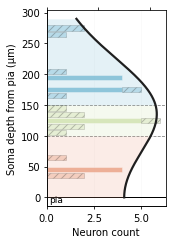

In [38]:
# %% Combined recorded-ROI + SWC soma-depth distribution
# One observation per unique recorded neuron, plus one observation per SWC reconstruction.
# Repeated longitudinal ROI observations are collapsed by subject_id + cell_id.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ---------------------------------------------------------------------
# Parameters
# ---------------------------------------------------------------------

BIN_WIDTH_UM = 10.0

DEPTH_GROUP_ORDER = ["<100 µm", "100–150 µm", ">150 µm"]

DEPTH_COLOR = {
    "<100 µm": "#EBA287",
    "100–150 µm": "#d1e2b0",
    ">150 µm": "#7bbcd5",
}


def depth_group_from_um(depth):
    if depth < 100:
        return "<100 µm"
    elif depth <= 150:
        return "100–150 µm"
    else:
        return ">150 µm"


# ---------------------------------------------------------------------
# Recorded physiology neurons
# ---------------------------------------------------------------------

roi_source = rois[
    rois["included"].astype(bool)
    & np.isfinite(pd.to_numeric(rois["depth_um"], errors="coerce"))
].copy()

roi_source["depth_um"] = pd.to_numeric(
    roi_source["depth_um"],
    errors="coerce",
)

# cell_id is the longitudinally registered identity in this notebook.
# Collapse repeated A0...B2 observations so each recorded neuron contributes once.
recorded_depths = (
    roi_source
    .groupby(["subject_id", "cell_id"], observed=True, as_index=False)
    .agg(
        soma_depth_um=("depth_um", "median"),
        n_sessions=("session_id", "nunique"),
    )
)

recorded_depths["source"] = "Recorded ROI"
recorded_depths["neuron_id"] = (
    recorded_depths["subject_id"].astype(str)
    + ":"
    + recorded_depths["cell_id"].astype(str)
)


# ---------------------------------------------------------------------
# Reconstructed neurons
# ---------------------------------------------------------------------

# soma_depths is generated in the preceding SWC-loading cell.
if "soma_depths" not in globals():
    raise NameError(
        "soma_depths is not defined. Run the preceding SWC soma-depth cell first."
    )

reconstructed_depths = (
    soma_depths[["swc_file", "soma_depth_um"]]
    .copy()
)

reconstructed_depths["soma_depth_um"] = pd.to_numeric(
    reconstructed_depths["soma_depth_um"],
    errors="coerce",
)
reconstructed_depths = reconstructed_depths.dropna(subset=["soma_depth_um"])

reconstructed_depths["source"] = "SWC reconstruction"
reconstructed_depths["neuron_id"] = reconstructed_depths["swc_file"].astype(str)


# ---------------------------------------------------------------------
# Combined population
# ---------------------------------------------------------------------

combined_depths = pd.concat(
    [
        recorded_depths[["neuron_id", "soma_depth_um", "source"]],
        reconstructed_depths[["neuron_id", "soma_depth_um", "source"]],
    ],
    ignore_index=True,
)

combined_depths["depth_group"] = combined_depths["soma_depth_um"].map(
    depth_group_from_um
)

if combined_depths.empty:
    raise RuntimeError("No recorded or reconstructed soma depths were available.")

if (combined_depths["soma_depth_um"] < 0).any():
    print(
        "WARNING: negative soma depths detected. "
        "This plot assumes pia = 0 µm and positive values extend deeper into cortex."
    )

print(
    f"Recorded neurons:      n = {len(recorded_depths)}\n"
    f"SWC reconstructions:   n = {len(reconstructed_depths)}\n"
    f"Combined observations: n = {len(combined_depths)}"
)

display(
    combined_depths
    .sort_values(["source", "soma_depth_um"])
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Histogram counts
# ---------------------------------------------------------------------

depth_values = combined_depths["soma_depth_um"].to_numpy(dtype=float)

depth_max = max(
    200.0,
    np.ceil(np.nanmax(depth_values) / BIN_WIDTH_UM) * BIN_WIDTH_UM
    + BIN_WIDTH_UM,
)

bins = np.arange(
    0.0,
    depth_max + BIN_WIDTH_UM,
    BIN_WIDTH_UM,
)

bin_centers = 0.5 * (bins[:-1] + bins[1:])

recorded_values = recorded_depths["soma_depth_um"].to_numpy(dtype=float)
reconstructed_values = reconstructed_depths["soma_depth_um"].to_numpy(dtype=float)

recorded_counts, _ = np.histogram(recorded_values, bins=bins)
reconstructed_counts, _ = np.histogram(reconstructed_values, bins=bins)
total_counts = recorded_counts + reconstructed_counts


# ---------------------------------------------------------------------
# Boundary-corrected KDE of the combined sample
# ---------------------------------------------------------------------

y_density = np.linspace(0.0, depth_max, 800)

if len(depth_values) >= 3 and np.nanstd(depth_values) > 0:
    # Reflect about the pia to avoid Gaussian density leaking into negative depth.
    reflected = np.concatenate([depth_values, -depth_values])
    kde = gaussian_kde(reflected, bw_method="scott")
    density = 2.0 * kde(y_density)
else:
    density = np.zeros_like(y_density)


# ---------------------------------------------------------------------
# Figure
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(2.5, 3.5))

# KDE gets its own horizontal scale so its shape is not compressed by counts.
ax_kde = ax.twiny()
ax_kde.patch.set_visible(False)

spans = [
    (0.0, 100.0, "<100 µm"),
    (100.0, 150.0, "100–150 µm"),
    (150.0, depth_max, ">150 µm"),
]


# ----- depth-group backgrounds -----

# for lo, hi, group in spans:
#     ax.axhspan(
#         lo,
#         hi,
#         color=DEPTH_COLOR[group],
#         alpha=0.10,
#         lw=0,
#         zorder=0,
#     )


# ----- stacked horizontal histogram -----
# Solid segment = recorded neurons.
# Hatched segment = SWC reconstructions.

for roi_n, swc_n, center, bottom, top in zip(
    recorded_counts,
    reconstructed_counts,
    bin_centers,
    bins[:-1],
    bins[1:],
):
    group = depth_group_from_um(center)
    color = DEPTH_COLOR[group]
    height = (top - bottom) * 0.86

    if roi_n > 0:
        ax.barh(
            center,
            roi_n,
            height=height,
            left=0,
            color=color,
            alpha=0.82,
            edgecolor="white",
            linewidth=0.6,
            zorder=2,
        )

    if swc_n > 0:
        ax.barh(
            center,
            swc_n,
            height=height,
            left=roi_n,
            color=color,
            alpha=0.42,
            edgecolor="0.30",
            linewidth=0.55,
            hatch="///",
            zorder=3,
        )


# ----- combined KDE on independent density axis -----

for lo, hi, group in spans:
    mask = (y_density >= lo) & (y_density <= hi)
    ax_kde.fill_betweenx(
        y_density[mask],
        0,
        density[mask],
        color=DEPTH_COLOR[group],
        alpha=0.20,
        linewidth=0,
        zorder=1,
    )

ax_kde.plot(
    density,
    y_density,
    color="0.12",
    lw=2.2,
    zorder=5,
)


# ---------------------------------------------------------------------
# Exact neuron positions
# ---------------------------------------------------------------------

max_count = max(float(total_counts.max()), 1.0)

# Two small columns to the left of the histogram distinguish data source.
recorded_rug_x = -0.16 * max_count
swc_rug_x = -0.06 * max_count

for _, row in recorded_depths.iterrows():
    depth = float(row["soma_depth_um"])
    group = depth_group_from_um(depth)

#     ax.scatter(
#         recorded_rug_x,
#         depth,
#         marker="o",
#         s=20,
#         color=DEPTH_COLOR[group],
#         edgecolor="black",
#         linewidth=0.35,
#         clip_on=False,
#         zorder=8,
#     )

for _, row in reconstructed_depths.iterrows():
    depth = float(row["soma_depth_um"])
    group = depth_group_from_um(depth)

#     ax.scatter(
#         swc_rug_x,
#         depth,
#         marker="D",
#         s=27,
#         color=DEPTH_COLOR[group],
#         edgecolor="black",
#         linewidth=0.45,
#         clip_on=False,
#         zorder=9,
#     )


# ---------------------------------------------------------------------
# Anatomical boundaries
# ---------------------------------------------------------------------

for boundary in (100, 150):
    ax.axhline(
        boundary,
        color="0.35",
        linestyle="--",
        lw=0.8,
        alpha=0.75,
        zorder=4,
    )

ax.axhline(
    0,
    color="black",
    lw=1.0,
    zorder=5,
)

ax.text(
    0.02 * max_count,
    3,
    "pia",
    ha="left",
    va="top",
    fontsize=9,
)


# ---------------------------------------------------------------------
# Main count axis
# ---------------------------------------------------------------------

ax.set_ylim(depth_max, 0)

# ax.set_xlim(
#     recorded_rug_x - 0.08 * max_count,
#     max_count * 1.16,
# )

ax.set_ylabel("Soma depth from pia (µm)")
ax.set_xlabel("Neuron count")

# ax.set_title(
#     "Recorded + reconstructed soma depths\n"
#     f"n = {len(recorded_depths)} recorded + "
#     f"{len(reconstructed_depths)} reconstructed",
#     pad=9,
# )

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.10, lw=0.6)
ax.tick_params(axis="both", length=3)


# ---------------------------------------------------------------------
# KDE density axis
# ---------------------------------------------------------------------

kde_max = max(float(np.nanmax(density)), 1e-9)

ax_kde.set_xlim(0, kde_max * 1.08)
ax_kde.set_ylim(ax.get_ylim())
# ax_kde.set_xlabel("Combined density")
# ax_kde.set_yticklabels([])
ax_kde.set_xticklabels([])

# ax_kde.spines[["bottom", "right"]].set_visible(False)
# ax_kde.tick_params(axis="x", length=3)


# ---------------------------------------------------------------------
# Legends
# ---------------------------------------------------------------------

source_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor="0.2",
        markersize=6,
        label="Recorded ROI",
    ),
    Line2D(
        [0], [0],
        marker="D",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor="0.2",
        markersize=6,
        label="SWC reconstruction",
    ),
]

# source_legend = ax.legend(
#     handles=source_handles,
#     title="Data source",
#     frameon=False,
#     loc="upper right",
# )
# ax.add_artist(source_legend)

depth_handles = [
    Patch(
        facecolor=DEPTH_COLOR[group],
        edgecolor="none",
        alpha=0.8,
        label=group,
    )
    for group in DEPTH_GROUP_ORDER
]

# ax.legend(
#     handles=depth_handles,
#     title="Soma depth",
#     frameon=False,
#     loc="lower right",
# )


plt.tight_layout()
plt.show()


# Optional export:
# fig.savefig(
#     "VIP_combined_soma_depth_distribution.pdf",
#     bbox_inches="tight",
#     transparent=True,
# )
#
# fig.savefig(
#     "VIP_combined_soma_depth_distribution.png",
#     dpi=600,
#     bbox_inches="tight",
#     transparent=True,
# )
import os
filen='SLAP2_neuron_depth'
save_figure(fig,os.path.join(savepath,filen),formats=['.pdf'],dpi=300)

### Combined depth-sampling figure

The final depth plot includes **each recorded physiology neuron once** (repeated longitudinal observations are collapsed by `subject_id + cell_id`) and **each SWC reconstruction once**. Histogram bars are stacked by data source, the rug markers distinguish recorded ROIs (circles) from SWCs (diamonds), and the KDE is computed from the combined population on an independent density axis.

> Note: the two sources are treated as distinct neuron sets. If an SWC file is known to correspond to a recorded ROI in `rois`, an explicit identity map should be added before combining them to avoid counting that neuron twice.
